# Day 08. Exercise 00
# Binary classifier. Logistic regression

In supervised learning:
In _classification_ problems, y=f(x) is _categorical._ If your target variable is continuous (for instance, a movie rating), it is called a _regression problem_.


In unsupervised learning:
* not require labels (target variable)
* it does not forecast anything
* it helps you to understand your data better

Examples: clustering algorithms, dimensionality reduction algorithms

__In this task__:
Now you need to train a classifier that can predict whether any given commit was made during working days or during weekends. Then you will be able to use the classifier to label the commits in the past when you had not been collecting the data.

Only two features: the number of commits before midday and the number of commits after midday.

## 0. Imports

In [183]:
import pandas as pd
from sklearn import linear_model
import sqlite3
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

## 1. Preprocessing

- Get the data from the file [`checker-timestamp.csv`](https://drive.google.com/file/d/1pooM4cITtG249msX3GK_6W0eEiblzAf5/view?usp=sharing).


- Create a dataframe `df` with the columns: `date`, `am`, `pm`, `target`, where `date` is the date of the day, `am` is the number of the commits during the day before midday (integer), `pm` is the number of commits during the day after midday (integer), `target` is weekend/working_day.

In [184]:
src_file = "../data/checker_timestamp.csv"

df_am = pd.read_csv(src_file, parse_dates=["timestamp"])
df_am["am"] = df_am["timestamp"].dt.hour.apply(lambda x: 1 if x < 12 else 0)
df_am["timestamp"] = df_am["timestamp"].dt.date


df_pm = pd.read_csv(src_file, parse_dates=["timestamp"])
df_pm["pm"] = df_pm["timestamp"].dt.hour.apply(lambda x: 0 if x < 12 else 1)
df_pm["timestamp"] = df_pm["timestamp"].dt.date

In [185]:
df_am = df_am.groupby(["timestamp"]).am.sum().reset_index()
df_pm = df_pm.groupby(["timestamp"]).pm.sum().reset_index()

In [186]:
df = df_am.merge(right=df_pm, on="timestamp", how="inner")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.rename(columns={"timestamp":"date"}, inplace=True)
df["target"] = df["date"].dt.dayofweek.apply(lambda x: "working_day" if x < 5 else "weekend")

In [187]:
display(df)

,date,am,pm,target
0,2020-04-17,21,2,working_day
1,2020-04-18,1,68,weekend
2,2020-04-19,18,15,weekend
3,2020-04-20,2,23,working_day
4,2020-04-21,0,25,working_day
5,2020-04-22,0,28,working_day
6,2020-04-23,10,33,working_day
7,2020-04-24,2,14,working_day
8,2020-04-25,30,74,weekend
9,2020-04-26,28,233,weekend


## 2. Exploratory analysis

- Create a plot where `x` is am, `y` is pm, each dot is a day, working days and weekends must have different colors.


- By looking at the graph do you think it will be easy to classify the days having those two features? Put your answer in the markdown cell in the end of that sectioin: "yes, it is easy" or "no, it is not easy".

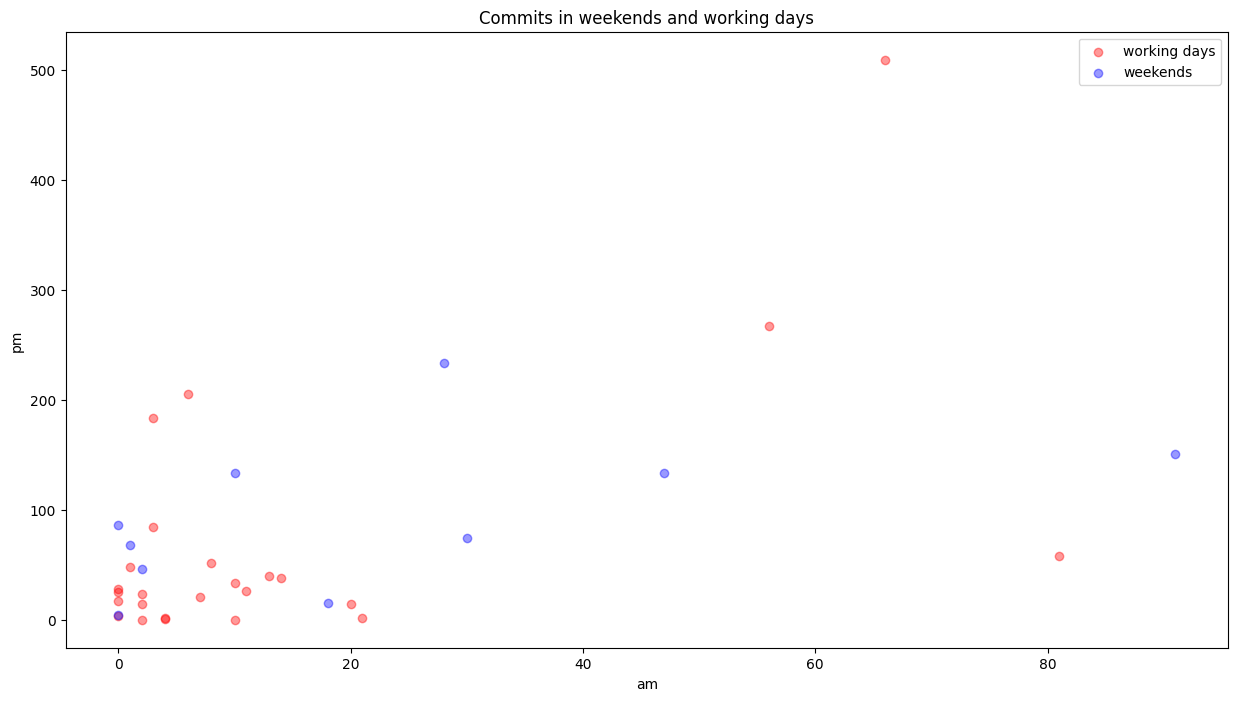

In [188]:
df_work = df[df["target"]=="working_day"]
df_weekend = df[df["target"] == "weekend"]

fig, ax = plt.subplots(figsize=(15, 8))
ax.scatter(x=df_work["am"], y=df_work["pm"], color="red", label="working days", alpha=0.4)
ax.scatter(x=df_weekend["am"], y=df_weekend["pm"], color="blue", label="weekends", alpha=0.4)
ax.set_xlabel("am")
ax.set_ylabel("pm")
ax.set_title("Commits in weekends and working days")
ax.legend()
plt.show()

No, it is not easy.

## 3. Logistic regression

- Train logistic regression on your data using `am` and `pm`, parameters are: `random state=21`, `fit_intercept=False`.


- Make predictions for every day of your dataset and add them to your dataframe with the column name `predict`.


- Save the dataframe into a file in the subfolder of the day `data` with the name `am_pm.csv`.


- Draw another plot like you did before, but the color should be taken from the `predict`.


- By looking at the graph do you think if it made good predictions? Put your answer in the markdown cell in the end of that section: "yes, it is good"; "no, it is not good".

In [189]:

reg = linear_model.LogisticRegression(random_state=21, fit_intercept=False)
X = df[["am", "pm"]].values
Y = df["target"]
reg.fit(X, Y)
df["predict"] = reg.predict(X)
display(df)

,date,am,pm,target,predict
0,2020-04-17,21,2,working_day,weekend
1,2020-04-18,1,68,weekend,working_day
2,2020-04-19,18,15,weekend,working_day
3,2020-04-20,2,23,working_day,working_day
4,2020-04-21,0,25,working_day,working_day
5,2020-04-22,0,28,working_day,working_day
6,2020-04-23,10,33,working_day,working_day
7,2020-04-24,2,14,working_day,working_day
8,2020-04-25,30,74,weekend,working_day
9,2020-04-26,28,233,weekend,working_day


In [190]:
df.to_csv("../data/am_pm.csv")

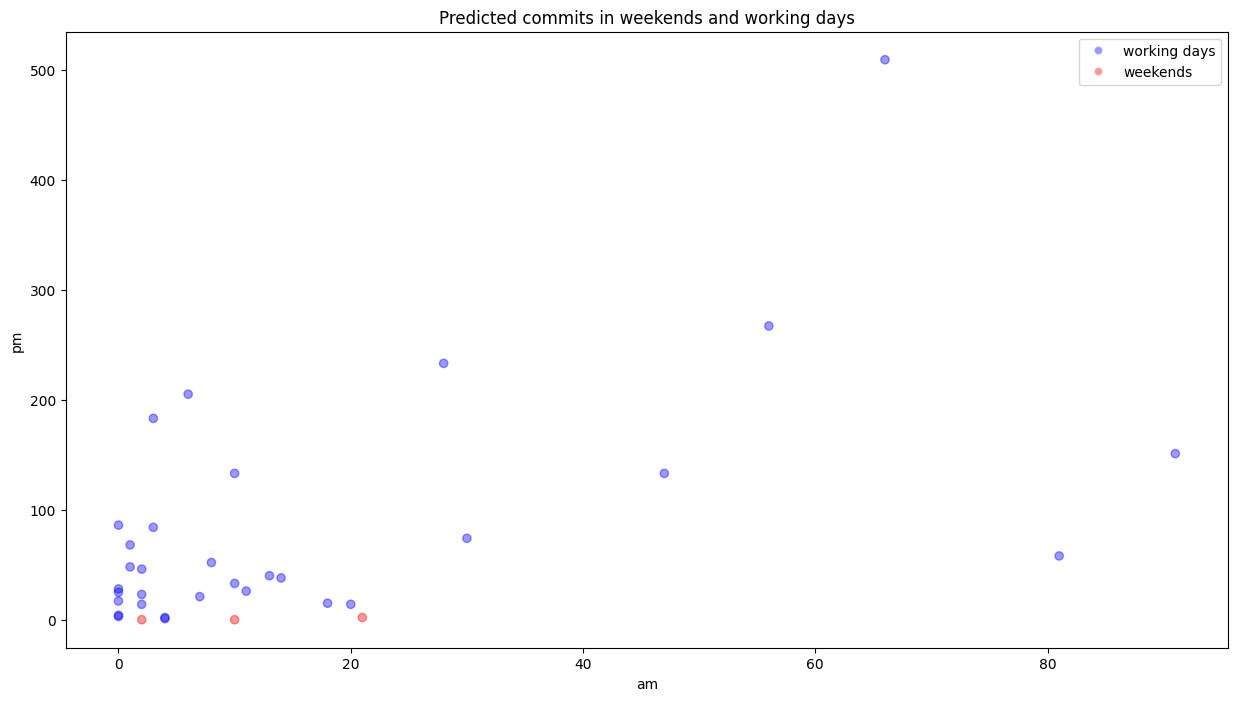

In [191]:

fig, ax = plt.subplots(figsize=(15, 8))
ax.scatter(x=df["am"], y=df["pm"], c = ["red" if x == "weekend" else "blue" for x in df["predict"]], alpha=0.4)
ax.set_xlabel("am")
ax.set_ylabel("pm")
ax.set_title("Predicted commits in weekends and working days")

legend_elements = [Line2D([0], [0], marker = 'o', color='w', markerfacecolor='blue', label='working days', alpha=0.4),
                   Line2D([0], [0], marker = 'o', color='w', markerfacecolor='red', label='weekends', alpha=0.4)]

ax.legend(handles=legend_elements)
plt.show()

No, it is not good.

## 4. Evaluation

- Calculate `accuracy` for your predictions.


- Calculate `accuracy` for the naive case when each of your prediction is the value of your most popular class of the day.


- Comparing the accuracies do you think that the classifier made good predictions? Put your answer in the markdown cell in the end of the secion: "yes, it is good"; "no, it is not good".

In [192]:
# acccuracy for predictions
accuracy = 0
try:
    for index, row in df.iterrows():
        accuracy += (row["predict"] == row["target"])

    accuracy /= len(df)
    print(f"Accuracy {accuracy * 100}%")
except ZeroDivisionError:
    print("Accuracy 0%")


Accuracy 62.857142857142854%


Насчет второй точности, самый популярная категория дня - это working day:

In [193]:
print(df['target'].value_counts())

working_day    25
weekend        10
Name: target, dtype: int64


In [194]:
# acccuracy for predictions as if df["targert"] contains only "working_day"
accuracy = 0
try:
    for index, row in df.iterrows():
        accuracy += (row["target"] == "working_day")

    accuracy /= len(df)
    print(f"Accuracy {accuracy * 100}%")
except ZeroDivisionError:
    print("Accuracy 0%")

Accuracy 71.42857142857143%


No, it is not good - так как этот классификатор в большенстве случаев предсказывал working day, а в изначальном датасете working day не так сильно превалирует.